Load Packages

In [8]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance


Load Data

In [2]:
REPO_DIR = Path("..")
DATA_DIR = REPO_DIR / "Data"

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv", index_col=0).squeeze("columns")


Create KNN pipeline

In [10]:
knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Hyperparameter tuning
param_grid = {
    'knn__n_neighbors': list(range(1, 31)),  # try k = 1 to 30
    'knn__weights': ['uniform', 'distance']  # optional improvement
}

knn_cv = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Fit model
knn_cv.fit(X_train, y_train)

# Predictions
y_pred = knn_cv.predict(X_test)

# Metrics 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best k:", knn_cv.best_params_['knn__n_neighbors'])
print("Best weights:", knn_cv.best_params_['knn__weights'])
print("RMSE:", rmse)
print("R^2:", r2)

Best k: 15
Best weights: distance
RMSE: 0.14745847645405935
R^2: 0.5902519214637703


In [ ]:

# Run importance on trained model
result = permutation_importance(
    knn_cv,   
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)

# Convert to Series 
importance = pd.Series(
    result.importances_mean,
    index=X_train.columns
)

importance_sorted = importance.sort_values(key=np.abs, ascending=False)

print("Top features:")
print(importance_sorted.head(20))

Top features:
PctTeen2Par         0.000398
racepctblack        0.000346
PctWOFullPlumb     -0.000303
PctIlleg            0.000297
pctWSocSec         -0.000232
PctSpeakEnglOnly    0.000231
MedNumBR           -0.000214
PctImmigRec5       -0.000211
PctLess9thGrade    -0.000201
PctLargHouseFam     0.000195
racePctWhite        0.000194
pctWFarmSelf       -0.000190
agePct65up         -0.000187
PctForeignBorn      0.000183
NumInShelters       0.000178
FemalePctDiv        0.000176
PctUsePubTrans      0.000173
PctFam2Par          0.000169
PctSameCity85      -0.000168
PopDens             0.000167
dtype: float64


Results:
The KNN model achieved optimal performance at k = 15 with distance weighting, indicating that a moderate neighborhood size and greater emphasis on closer observations improved predictions. The model produced an RMSE of 0.147 and an R^2 of 0.59, suggesting moderate predictive accuracy. Feature importance, assessed using permutation importance, indicating that demographic and socioeconomic variables were the most influential though importance values were relatively small due to the model’s distance-based structure. Overall, KNN captured meaningful patterns in the data but offered less interpretability than parametric approaches.


Tran vs. Test comparison

In [13]:
print("Train R^2:", knn_cv.score(X_train, y_train))
print("Test R^2:", knn_cv.score(X_test, y_test))

Train R^2: -1.891786005227503e-15
Test R^2: -0.021744002278152375


The KNN model produced a training R^2 of approximately 0 and a test R^2of −0.022, indicating that the model performs no better than predicting the mean of the response variable and slightly worse on unseen data. This suggests that the model is underfitting and failing to capture meaningful relationships between the predictors and the outcome. Despite cross-validation selecting k=15, the relatively large neighborhood size likely oversmooths the data, reducing the model’s ability to learn underlying patterns. Overall, these results indicate that KNN may not be well-suited for this dataset, potentially due to high dimensionality or weak local structure in the predictors.

Visualizations 

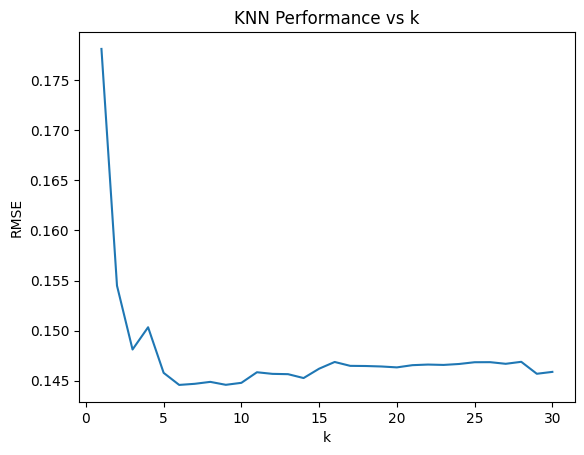

In [15]:
k_values = range(1, 31)
rmse_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_scores.append(rmse)

plt.plot(k_values, rmse_scores)
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("KNN Performance vs k")
plt.show()

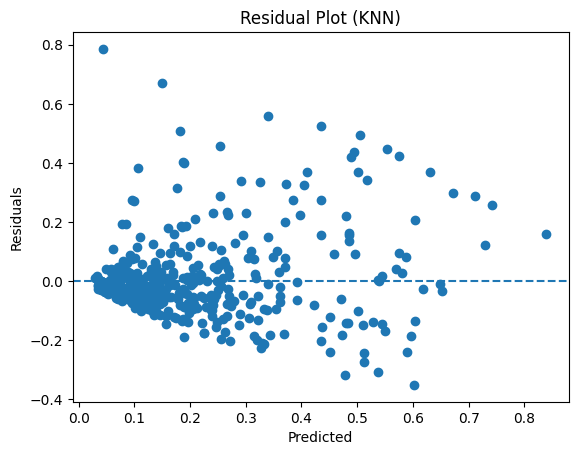

In [16]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (KNN)")
plt.show()

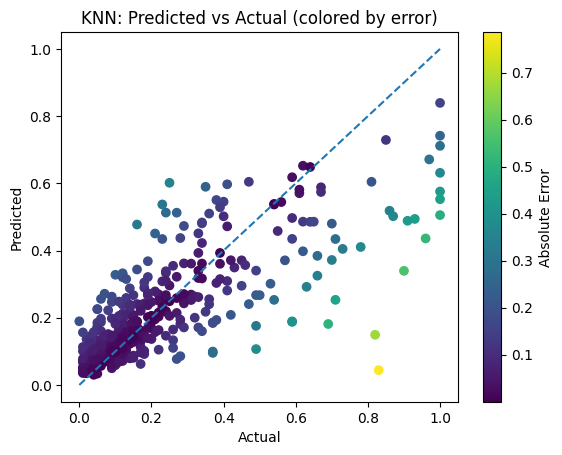

In [17]:
import matplotlib.pyplot as plt
import numpy as np

errors = np.abs(y_test - y_pred)

plt.scatter(y_test, y_pred, c=errors)
plt.colorbar(label="Absolute Error")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN: Predicted vs Actual (colored by error)")
plt.show()